# Bat Echolocation Feature Extraction
Goal: Extract features from bat echolocation calls, remove outliers, then average across all calls in a bat pass

--> Program is semi-automated, so you run cells at the top and then add filename and adjust thresholds until the calls are correctly highlighted using the waveform/spectrogram, then run the rest of the program and it will export your results in a csv.

Steps:
1. Input a file
2. Apply high-pass filter to remove lower-frequency background noise below the bat calls. Low-pass filter optional if needed.
3. Normalize amplitude
4. Visualize
5. Use voice activity detection (VAD) with energy cutoff to get the timestamps for the bat calls and inter-call intervals (ICIs)
6. For each call within the bat pass (excluding first and last which could be cut off), extract the following features:
    - start time
    - end time
    - call duration
    - time until the next call
    - min frequency
    - max frequency
    - frequency of most energy
    - slope estimate assuming downward shape
7. Show those results in a table, with each column being a feature, and each row being a call
8. Check for outliers on each feature and remove calls with outliers
9. Check for presence of feeding buzzes, and extract the duration and min_freq in the feeding buzz
10. Get averages for the features and prep for export

Author: K Rubio
Last modified: 9/17/2025

In [1]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import zscore

## Helper Methods

In [2]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=sr, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [3]:
# Create method to easily plot spectrograms
def plot_spectrogram(Y, sr, hop_length, y_axis="mel", fmin=0, fmax=20000):
    plt.figure(figsize=(25, 10)) # instantiate a figure and give a size
    # use librosa.display.specshow to visualize any type of spectrogram
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis
		)
    plt.ylim(fmin, fmax)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')    
    plt.colorbar(format="%+2.f") # add a color bar legend
    plt.title('Spectrogram')
    plt.show()

In [4]:
# Create method to easily plot spectrograms AND zoom in on the x-axis
def plot_spectrogram_zoom(Y, sr, hop_length, y_axis="mel", fmin=0, fmax=20000, xmin=0, xmax=12):
    plt.figure(figsize=(25, 10)) # instantiate a figure and give a size
    # use librosa.display.specshow to visualize any type of spectrogram
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis
		)
    plt.ylim(fmin, fmax)
    plt.xlim(xmin, xmax)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')    
    plt.colorbar(format="%+2.f") # add a color bar legend
    plt.title('Spectrogram')
    plt.show()

In [5]:
# normalize audio signal so volume is consistent across files
def rms_normalize(y, target_dBFS=-30.0):
    rms = np.sqrt(np.mean(y**2))
    current_dBFS = 20 * np.log10(rms + 1e-9)
    gain = 10 ** ((target_dBFS - current_dBFS) / 20)
    return y * gain

In [6]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that separates a group of sound
# Returns periods of time with voice activity separated by silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_voice_activity_timestamps(*, vad_output: List[int], frame_shift: int, min_silence_duration: int = 1000):
    min_silence_frames = int(min_silence_duration / frame_shift)

    groups = []
    start_idx = None
    silence_counter = 0

    for i, frame in enumerate(vad_output):
        if frame == 1:
            if start_idx is None:
                start_idx = i
            silence_counter = 0
        else:
            if start_idx is not None:
                silence_counter += 1
                if silence_counter >= min_silence_frames:
                    # Silence is long enough, so close the current voice group
                    end_idx = i - silence_counter
                    start_time = start_idx * frame_shift / 1000
                    end_time = (end_idx + 1) * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 4),
                        'end': round(end_time, 4)
                    })
                    start_idx = None
                    silence_counter = 0

    # Handle case where audio ends with voice activity
    if start_idx is not None:
        end_time = (len(vad_output)+1) * frame_shift / 1000
        groups.append({
            'start': round(start_idx * frame_shift / 1000, 4),
            'end': round(end_time, 4)
        })

    return groups

In [7]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that will be included
# Returns timestamps for silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_timestamps_silences(*, vad_output: List[int], frame_shift: int, min_silence_duration: int=1000):
    min_silence_frames = int(min_silence_duration / frame_shift)
    groups = []
    start_idx = None

    for i, frame in enumerate(vad_output):
        if frame==0:
            if start_idx is None:
                start_idx = i
        else:
            if start_idx is not None:
                end_idx = i
                duration = end_idx - start_idx

                if duration >= min_silence_frames:
                    start_time = start_idx * frame_shift / 1000
                    end_time = end_idx * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 2),
                        'end': round(end_time, 2)
                    })

                start_idx = None

    # Handle case where the last segment goes to the end
    if start_idx is not None:
        end_idx = len(vad_output)
        duration = end_idx - start_idx
        if duration >= min_silence_frames:
            start_time = start_idx * frame_shift / 1000
            end_time = end_idx * frame_shift / 1000
            groups.append({
                'start': round(start_time, 2),
                'end': round(end_time, 2)
            })

    return groups

In [8]:
# Convert timestamps into durations
# Returns timestamps in format {'start': time in seconds, 'end': time in seconds}
def convert_timestamps_to_durations(timestamps):
    durations = []
    for i, timestamps in enumerate(timestamps):
        durations.append(round(float(timestamps['end'])-float(timestamps['start']), 4))
    return durations

In [9]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps, sr):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * sr) # convert start time into sample index
        end_sample = int(float(ts['end']) * sr)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [10]:
# Function that takes in:
    #   stft_abs which comes from stft = librosa.stft() && stft_abs = np.abs(stft_bat) 
    #   and where filters for background noise have already been applied
    #   times, which comes from librosa.frames_to_time()
    #   the start and end times (in seconds) of the call
    #   an energy cutoff, for instance, what's the minimum energy that something has to have
    #   to be considered part of the sound
# Function returns the min frequency, the max frequency, and the frequency with most energy (Hz)
def extractMinMaxAndMostEnergyFrequencies(stft_abs, times, start_time, end_time, energy_cutoff, bat_frequencies):
    # slice time window for the first bat call
    time_mask = (times >= start_time) & (times <= end_time)
    stft_call = stft_abs[:, time_mask]
    
    # energy per frequency bin
    energy_per_freq = stft_call.mean(axis=1)

    # normalize
    energy_norm = energy_per_freq / energy_per_freq.max()

    # cutoff mask
    mask = energy_norm >= energy_cutoff

    # get results
    min_freq = bat_frequencies[mask].min()
    max_freq = bat_frequencies[mask].max()
    max_energy_freq = bat_frequencies[np.argmax(energy_per_freq)]

    # return results
    return {'min_freq': min_freq, 'max_freq': max_freq, 'max_energy_freq': max_energy_freq}

## File input and Thresholds to adjust

In [1303]:
filename = 'bat_20250909_1940.wav'
sr = 384000
# High pass filter cutoff to zero out frequencies below bat sounds --> adjust after checking spectrogram
CUTOFF = 26000 # Hz

# Spectrogram visualization settings
SPECTROGRAM_MIN_FREQ = CUTOFF
SPECTROGRAM_MAX_FREQ = 100000

# VAD Settings --> adjust these depending on how fast the bat is making sounds
FRAME_LENGTH = 5 # milliseconds
FRAME_SHIFT = 2 # milliseconds
# Generally a silence longer than 90ms is should separate one search call from another
MIN_ICI = 20 # in milliseconds
# call might be 19ms (3-50ms) or 0.5ms for micro-calls, while a ICI might be like 228ms
# Search phase ICI's are ~100 ms or longer
# Approach phase ICI's are ~20 ms
# Feeding buzz ICI's are ~9-18 ms

In [1304]:
# Load audio with Librosa.load and sample at the correct rate
file, sr = librosa.load(filename, sr=sr)
# Apply the Short-Time Fourier Transform to convert to the frequency domain
FRAME_LENGTH_SPEC = 2048
HOP_LENGTH_SPEC = FRAME_LENGTH_SPEC//4
stft_bat = librosa.stft(file, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat.shape
stft_bat_abs = np.abs(stft_bat) ** 2

In [1305]:
# Apply High Pass Filter
# Filter out lower frequency background noise by zeroing out all values below a cutoff
bat_frequencies = librosa.fft_frequencies(sr=sr, n_fft=FRAME_LENGTH_SPEC)
cutoff_idx = np.argmax(bat_frequencies >= CUTOFF)
stft_bat_filtered = stft_bat.copy()
stft_bat_filtered[:cutoff_idx, :] = 0
stft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2
bat_filtered = librosa.istft(stft_bat_filtered, hop_length=HOP_LENGTH_SPEC)

In [1306]:
# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy
bat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)
stft_bat = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat_filtered_abs = np.abs(stft_bat) ** 2
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

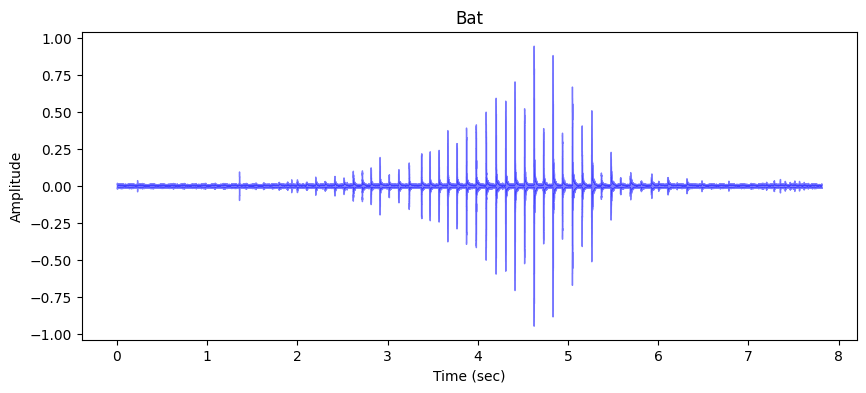

In [1307]:
# Plot waveform
plotWaveform(bat_filtered_normalized, 'Bat')

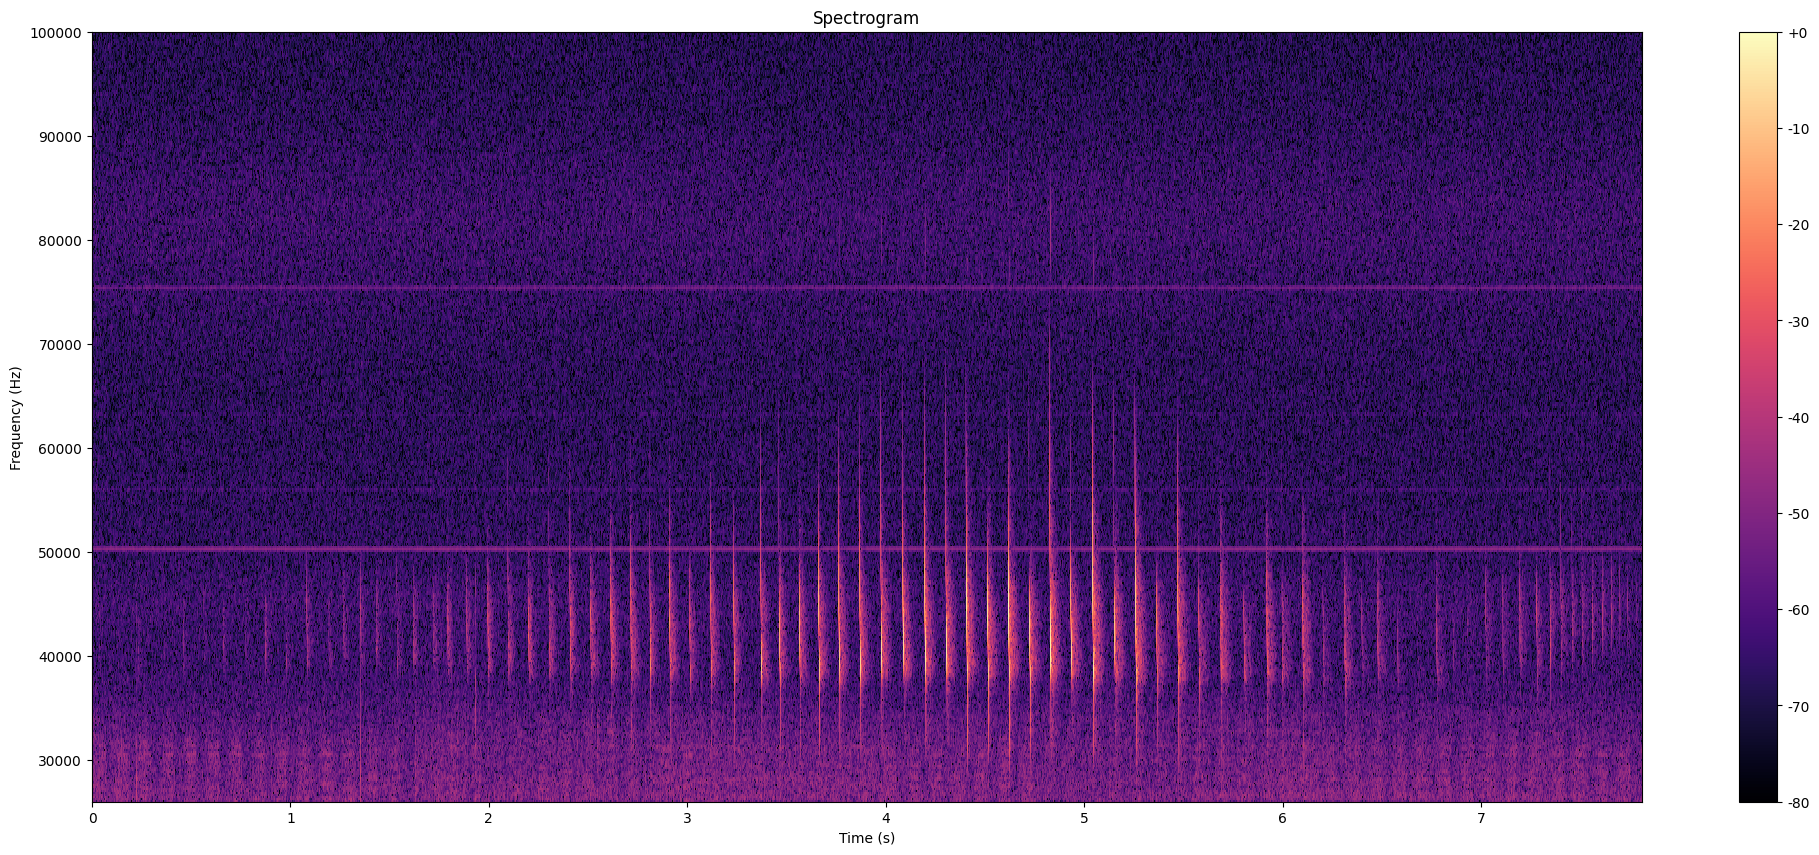

In [1308]:
# Plot spectrogram
plot_spectrogram(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    SPECTROGRAM_MIN_FREQ,
    SPECTROGRAM_MAX_FREQ)

In [1309]:
# OPTIONAL Low Pass Filter - Filter out higher frequencies
'''
HIGH_CUTOFF = 49000
cutoff_idx_high = np.argmax(bat_frequencies >= HIGH_CUTOFF)
stft_bat_filtered = stft_bat_filtered.copy()
stft_bat_filtered[cutoff_idx_high:, :] = 0
stft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2
bat_filtered = librosa.istft(stft_bat_filtered, hop_length=HOP_LENGTH_SPEC)

# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy
bat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)
stft_bat = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat_filtered_abs = np.abs(stft_bat) ** 2
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

# Plot spectrogram
plot_spectrogram(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    SPECTROGRAM_MIN_FREQ,
    HIGH_CUTOFF+ 10000)
'''

'\nHIGH_CUTOFF = 49000\ncutoff_idx_high = np.argmax(bat_frequencies >= HIGH_CUTOFF)\nstft_bat_filtered = stft_bat_filtered.copy()\nstft_bat_filtered[cutoff_idx_high:, :] = 0\nstft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2\nbat_filtered = librosa.istft(stft_bat_filtered, hop_length=HOP_LENGTH_SPEC)\n\n# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy\nbat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)\nstft_bat = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)\nstft_bat_filtered_abs = np.abs(stft_bat) ** 2\nstft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)\n\n# Plot spectrogram\nplot_spectrogram(\n    stft_bat_filtered_dB,\n    sr,\n    HOP_LENGTH_SPEC,\n    "linear",\n    SPECTROGRAM_MIN_FREQ,\n    HIGH_CUTOFF+ 10000)\n'

In [1310]:
# !!! Help picking an energy threshold
# fill out the number of expected calls you'd expect to see based on the waveform and
# spectrogram that are LOUDER than wind. Include non-call sounds that are as 
# loud as the calls and above the frequency cutoff --> these will be removed later 
# if they're outliers
NUM_OF_CALLS = 30

In [1311]:
# Automated choosing energy threshold based on user estimate of
# number of calls, using lowest possible energy threshold that gets
# close to that number.
# Goal is for the program to correctly highlight the calls below
energy_threshold = 0.01
num_of_calls = 0
max_runs = 1000
run = 0

while num_of_calls < NUM_OF_CALLS - 1 and run < max_runs:
    
    # energy_threshold += 0.01
    energy_threshold = energy_threshold + 0.01
    vad = EnergyVAD(
        frame_length=FRAME_LENGTH,
        frame_shift=FRAME_SHIFT,
        sample_rate=sr,
        energy_threshold=energy_threshold)
    vad_output = vad(bat_filtered_normalized)
    # Get timestamps for calls
    calls = get_voice_activity_timestamps(
        vad_output=vad_output,
        frame_shift=FRAME_SHIFT,
        min_silence_duration=MIN_ICI)
    num_of_calls = len(calls)
    run += 1
print(f'Energy threshold should be at least: {energy_threshold:2f} identified {len(calls)} calls but raise as needed')
ENERGY_THRESHOLD = energy_threshold

Energy threshold should be at least: 0.030000 identified 70 calls but raise as needed


In [1312]:
# re-adjust energy threshold as needed to make sure waveform below makes sense
ENERGY_THRESHOLD = 0.03

In [1313]:
# VAD
vad = EnergyVAD(
    frame_length=FRAME_LENGTH,
    frame_shift=FRAME_SHIFT,
    sample_rate=sr,
    energy_threshold=ENERGY_THRESHOLD)
vad_output = vad(bat_filtered_normalized)
# Get timestamps for calls
calls = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)

# Get timestamps for silences between calls
icis = get_timestamps_silences(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
# If the first ICI starts at 0, cut it off since we don't want that at the beginning
if len(icis) > 0 and icis[0]['start'] == 0:
    icis = icis[1:]
print(f'Identified {len(calls)} call(s) and {len(icis)} silences')
if len(calls) < 4:
    print('Error! This is not enough calls. Try increasing the ENERGY_THRESHOLD')

Identified 70 call(s) and 70 silences


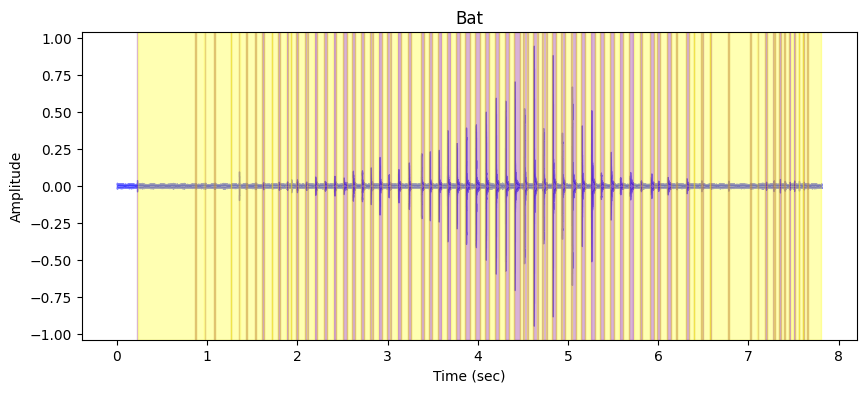

In [1314]:
plotWaveform(bat_filtered_normalized, 'Bat', calls, icis)

In [1315]:
# If there are more calls than ICI's, cut the last call out
if len(calls) > len(icis):
    calls = calls[:-1]

In [1316]:
# Extract time data
starts = []
ends = []
durations_ms = []
for call in calls:
    starts.append(call['start'])
    ends.append(call['end'])
    durations_ms.append((call['end'] - call['start']) * 1000)
start_end_data = {'start': starts, 'end': ends, 'duration_ms': durations_ms}
df = pd.DataFrame(start_end_data)
# Add time_to_next_call_ms to the dataframe
time_to_next_call_ms = []
for ici in icis:
    time_to_next_call_ms.append((ici['end'] - ici['start']) * 1000)
df['time_to_next_call_ms'] = time_to_next_call_ms

In [1317]:
# Frequency domain data
times = librosa.frames_to_time(np.arange(stft_bat_filtered_abs.shape[1]),
                               sr=sr,
                               hop_length=HOP_LENGTH_SPEC)
frequency_data = []
for call in calls:
    energy_cutoff = 0.04
    call_data = extractMinMaxAndMostEnergyFrequencies(
        stft_bat_filtered_abs,
        times,
        call['start'],
        call['end'],
        energy_cutoff,
        bat_frequencies)
    frequency_data.append(call_data)
# Add these as columns to the data frame
min_freqs = []
max_freqs = []
max_energy_freqs = []
for row in frequency_data:
    min_freqs.append(row['min_freq'])
    max_freqs.append(row['max_freq'])
    max_energy_freqs.append(row['max_energy_freq'])
df['min_freq'] = min_freqs
df['max_freq'] = max_freqs  
df['max_energy_freq'] = max_energy_freqs
# Calculate simple slopes for all calls and add to table
df['slope'] = (df['min_freq'] - df['max_freq']) / ((df['end'] - df['start']) * 1000)
df.head()

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.220,0.226,6.0,640.0,25875.0,150750.0,28312.5,-20812.50
1,0.870,0.876,6.0,90.0,26062.5,150937.5,40312.5,-20812.50
2,0.974,0.978,4.0,100.0,26062.5,150937.5,30562.5,-31218.75
3,1.078,1.088,10.0,170.0,25875.0,150937.5,43687.5,-12506.25
4,1.262,1.268,6.0,80.0,25875.0,155062.5,43875.0,-21531.25


In [1318]:
# Check df
df

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.220,0.226,6.0,640.0,25875.0,150750.0,28312.5,-20812.500000
1,0.870,0.876,6.0,90.0,26062.5,150937.5,40312.5,-20812.500000
2,0.974,0.978,4.0,100.0,26062.5,150937.5,30562.5,-31218.750000
3,1.078,1.088,10.0,170.0,25875.0,150937.5,43687.5,-12506.250000
4,1.262,1.268,6.0,80.0,25875.0,155062.5,43875.0,-21531.250000
...,...,...,...,...,...,...,...,...
65,7.454,7.466,12.0,30.0,26250.0,150937.5,42000.0,-10390.625000
66,7.504,7.518,14.0,40.0,25875.0,150750.0,43875.0,-8919.642857
67,7.556,7.564,8.0,50.0,26062.5,150937.5,44437.5,-15609.375000
68,7.608,7.614,6.0,40.0,26062.5,150937.5,44812.5,-20812.500000


In [1319]:
# Data cleaning

In [1320]:
# OPTIONAL - Drop first and last row, as first and last call may be cut off, and/or have 
# innacurate time_to_next_call
df2 = df.iloc[1:-1]
# df2 = df

In [1321]:
# drop outliers
# Look at duration outliers, first create a copy of the original data frame (to preserve original indexing)
df_zscores = df2.copy()
df_zscores.drop(['duration_ms', 'time_to_next_call_ms', 'min_freq', 'max_freq', 'max_energy_freq', 'slope'], axis=1, inplace=True)
df_zscores['duration_ms'] = zscore(df2['duration_ms'])
df_zscores['time_to_next_call_ms'] = zscore(df2['time_to_next_call_ms'])
df_zscores['min_freq'] = zscore(df2['min_freq'])
df_zscores['max_freq'] = zscore(df2['max_freq'])
df_zscores['max_energy_freq'] = zscore(df2['max_energy_freq'])
df_zscores['slope'] = zscore(df2['slope'])

duration_outliers = df_zscores[abs(df_zscores['duration_ms']) > 3].index.tolist()
time_to_next_call_ms_outliers = df_zscores[abs(df_zscores['time_to_next_call_ms']) > 3].index.tolist()
min_freq_outliers = df_zscores[abs(df_zscores['min_freq']) > 3].index.tolist()
max_freq_outliers = df_zscores[abs(df_zscores['max_freq']) > 3].index.tolist()
max_energy_freq_outliers = df_zscores[abs(df_zscores['max_energy_freq']) > 3].index.tolist()
slope_outliers = df_zscores[abs(df_zscores['slope']) > 3].index.tolist()

df3 = df2.copy()
for outlier in duration_outliers:
    df3.loc[outlier, 'duration_ms'] = np.nan
for outlier in time_to_next_call_ms_outliers:
    df3.loc[outlier, 'time_to_next_call_ms'] = np.nan
for outlier in min_freq_outliers:
    df3.loc[outlier, 'min_freq'] = np.nan
for outlier in max_freq_outliers:
    df3.loc[outlier, 'max_freq'] = np.nan
for outlier in max_energy_freq_outliers:
    df3.loc[outlier, 'max_energy_freq'] = np.nan
for outlier in slope_outliers:
    df3.loc[outlier, 'slope'] = np.nan
df3


,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.870,0.876,6.0,90.0,26062.5,150937.5,40312.5,-20812.500000
2,0.974,0.978,4.0,100.0,26062.5,150937.5,30562.5,-31218.750000
3,1.078,1.088,10.0,NaN,25875.0,150937.5,43687.5,-12506.250000
4,1.262,1.268,6.0,80.0,25875.0,155062.5,43875.0,-21531.250000
5,1.350,1.356,6.0,70.0,25875.0,50250.0,NaN,-4062.500000
...,...,...,...,...,...,...,...,...
64,7.398,7.410,12.0,40.0,26062.5,150750.0,45000.0,-10390.625000
65,7.454,7.466,12.0,30.0,26250.0,150937.5,42000.0,-10390.625000
66,7.504,7.518,14.0,40.0,25875.0,150750.0,43875.0,-8919.642857
67,7.556,7.564,8.0,50.0,26062.5,150937.5,44437.5,-15609.375000


In [1322]:
# Final statistics on the bat pass
# Generate key features from this bat pass and save in a dictionary
avg_duration_ms = df3['duration_ms'].mean()
avg_ici = df3['time_to_next_call_ms'].mean()
avg_min_freq = df3['min_freq'].mean() / 1000
avg_max_freq = df3['max_freq'].mean() / 1000
avg_freq_of_most_energy = df3['max_energy_freq'].mean() / 1000
avg_slope = df3['slope'].mean()
bat_pass_features = {
    'filename': filename,
    'duration_ms': avg_duration_ms,
    'ici_ms': avg_ici,
    'min_freq': avg_min_freq,
    'max_freq': avg_max_freq,
    'freq_of_most_energy': avg_freq_of_most_energy,
    'slope': avg_slope,
}
print(f' Bat pass features: {filename}')
print(f'Number of calls {len(calls)}')
print(f'Average call duration: {avg_duration_ms:.2f} ms')
print(f'Average ICI: {avg_ici:.2f} ms')
print(f'Average min frequency: {avg_min_freq:.2f} kHz')
print(f'Average max frequency: {avg_max_freq:.2f} kHz')
print(f'Average frequency with most energy: {avg_freq_of_most_energy:.2f} kHz')
print(f'Average call slope: {avg_slope:.2f} Hz/ms')


 Bat pass features: bat_20250909_1940.wav
Number of calls 70
Average call duration: 28.18 ms
Average ICI: 66.00 ms
Average min frequency: 30.79 kHz
Average max frequency: 91.70 kHz
Average frequency with most energy: 41.50 kHz
Average call slope: -5837.05 Hz/ms


In [1275]:
# Export results to excel
columns=['filename','duration_ms','ici_ms','min_freq','max_freq','freq_of_most_energy','slope']
results = pd.DataFrame([bat_pass_features], columns=columns)
results.to_csv("output/output.csv", mode="a", header=False, index=False)